In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn scikit-surprise


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554980 sha256=a1788e87489a8b35d0b3b57915257746201d3ec65c60312b7d5d7a8338a68721
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [4]:
from google.colab import files
files.upload()



Output hidden; open in https://colab.research.google.com to view.

In [9]:
import zipfile

with zipfile.ZipFile("ml-latest-small.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [8]:
import pandas as pd

ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")

In [10]:
ratings.head()
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
#tien xu ly

In [11]:
ratings.isnull().sum()
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [12]:
ratings = ratings[["userId", "movieId", "rating"]]
movies = movies[["movieId", "title", "genres"]]

In [11]:
#xu ly genres
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [12]:
#xu ly phim khong co genre
movies["genres"].value_counts().head()


,count
genres,
Drama,1053
Comedy,946
Comedy Drama,435
Comedy Romance,363
Drama Romance,349


In [13]:
data = ratings.merge(movies, on="movieId")
data.head()


,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy Romance
2,1,6,4.0,Heat (1995),Action Crime Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime Mystery Thriller


In [14]:
ratings_cf = ratings.copy()
movies_cb = movies.copy()


In [15]:
#phan tich du lieu

In [16]:
print("Số dòng ratings:", ratings.shape[0])
print("Số cột ratings:", ratings.shape[1])

print("Số dòng movies:", movies.shape[0])
print("Số cột movies:", movies.shape[1])


Số dòng ratings: 100836
Số cột ratings: 3
Số dòng movies: 9742
Số cột movies: 3


In [17]:
#so luong user/movie
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()

print("Số user:", n_users)
print("Số phim:", n_movies)


Số user: 610
Số phim: 9724


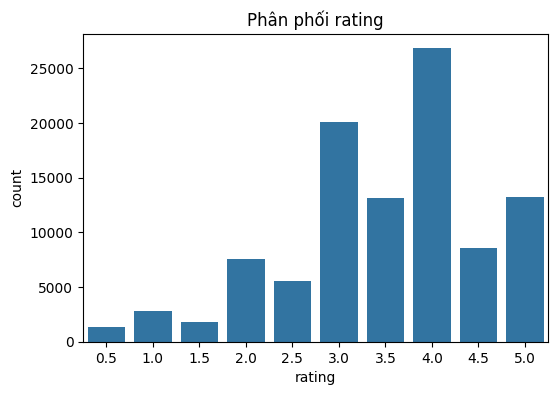

In [18]:
#phan phoi rating
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=ratings)
plt.title("Phân phối rating")
plt.show()

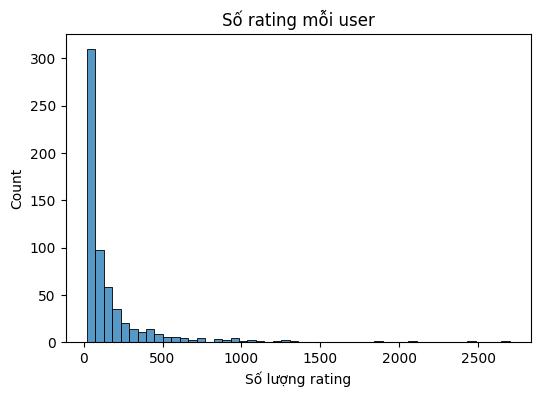

In [19]:
# so rating moi user
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_user, bins=50)
plt.title("Số rating mỗi user")
plt.xlabel("Số lượng rating")
plt.show()


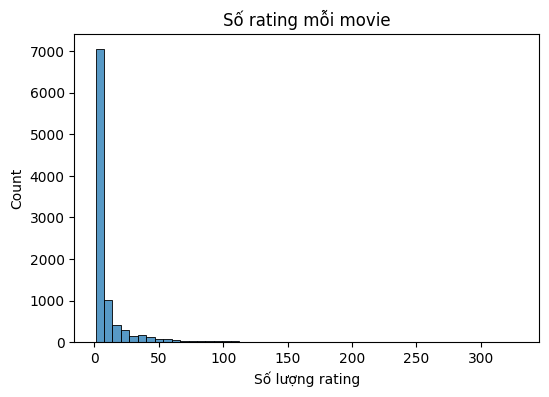

In [20]:
# so rating moi movie
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_movie, bins=50)
plt.title("Số rating mỗi movie")
plt.xlabel("Số lượng rating")
plt.show()


In [21]:
#Độ thưa (Sparsity)
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print("Sparsity:", sparsity)


Sparsity: 0.9830003169443864


In [22]:
#Collaborative Filtering:

In [23]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install scikit-surprise


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 113.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is i

In [25]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
from surprise import SVD, KNNBasic


In [26]:
reader = Reader(rating_scale=(0.5, 5.0))


In [27]:
data_surprise = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)


In [28]:
trainset, testset = train_test_split(
    data_surprise,
    test_size=0.2,
    random_state=42
)


In [29]:
#SVD

In [30]:
#train
from surprise import SVD

svd = SVD(random_state=42)
svd.fit(trainset)


In [31]:
# du doan test
predictions_svd = svd.test(testset)


In [35]:
# danh gia RMSE & MAE
rmse_svd = accuracy.rmse(predictions_svd)
mae_svd  = accuracy.mae(predictions_svd)

# danh gia recall & precision
# ham tinh
from collections import defaultdict
import numpy as np

def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():

        # Sắp xếp theo estimated rating giảm dần
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Top K
        user_ratings_k = user_ratings[:k]

        # Relevant items (rating thật >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Recommended items
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings_k)

        # Relevant & recommended
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings_k
        )

        precisions[uid] = (
            n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        )

        recalls[uid] = (
            n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        )

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))



RMSE: 0.8807
MAE:  0.6766


In [36]:
precision_svd, recall_svd = precision_recall_at_k(
    predictions_svd, k=10, threshold=3.5
)

print("SVD Precision@10:", precision_svd)
print("SVD Recall@10:", recall_svd)


SVD Precision@10: 0.7446291959406715
SVD Recall@10: 0.5086160453516003


In [19]:
#KNN

In [20]:
from surprise import KNNBasic

sim_options = {
    "name": "cosine",
    "user_based": True   # User-based CF
}


In [21]:
#train
knn = KNNBasic(sim_options=sim_options)
knn.fit(trainset)


Computing the cosine similarity matrix...
Done computing similarity matrix.


In [22]:
# du doan test
predictions_knn = knn.test(testset)

In [37]:
#danh gia RMSE & MAE
rmse_knn = accuracy.rmse(predictions_knn)
mae_knn  = accuracy.mae(predictions_knn)

# danh gia recall & precision
# ham tinh
from collections import defaultdict
import numpy as np

def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():

        # Sắp xếp theo estimated rating giảm dần
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Top K
        user_ratings_k = user_ratings[:k]

        # Relevant items (rating thật >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Recommended items
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings_k)

        # Relevant & recommended
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings_k
        )

        precisions[uid] = (
            n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        )

        recalls[uid] = (
            n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        )

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))


RMSE: 0.9823
MAE:  0.7559


In [38]:
precision_knn, recall_knn = precision_recall_at_k(
    predictions_knn, k=10, threshold=3.5
)

print("KNN Precision@10:", precision_knn)
print("KNN Recall@10:", recall_knn)


KNN Precision@10: 0.7572014051522248
KNN Recall@10: 0.5416431952067678


In [39]:
# so sanh danh gia
import pandas as pd

results = pd.DataFrame({
    "Model": ["SVD", "KNN"],
    "RMSE": [rmse_svd, rmse_knn],
    "MAE": [mae_svd, mae_knn],
    "Precision@10": [precision_svd, precision_knn],
    "Recall@10": [recall_svd, recall_knn]
})

results


,Model,RMSE,MAE,Precision@10,Recall@10
0,SVD,0.880746,0.676573,0.744629,0.508616
1,KNN,0.982256,0.755897,0.757201,0.541643


In [40]:
# content-based

In [41]:
#xu ly genres
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)


In [42]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["genres"])


In [43]:
# Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape


(9742, 9742)

In [44]:
# ham recomend
indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def recommend_movies(title, cosine_sim=cosine_sim, top_n=10):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movies["title"].iloc[movie_indices]


In [45]:
recommend_movies("Toy Story (1995)")


,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)
